In [7]:
import os
import json
import torch
import pandas as pd
import logging
import importlib
from pathlib import Path
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image as PILImage
from IPython.display import Image

import sys
PROJECT_DIR = "/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER"
SRC_DIR = str(Path(PROJECT_DIR) / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import multiomic_transformer.utils.data_formatter as data_formatter
import multiomic_transformer.utils.experiment_handler as experiment_handler

random.seed(1337)
np.random.seed(1337)
torch.manual_seed(1337)

GROUND_TRUTH_DIR = Path(PROJECT_DIR) / "data" / "ground_truth_files"
DATA_DIR = Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/")
STABILITY_EXPERIMENT_DIR = DATA_DIR / "EXPERIMENTS" / "STABILITY"

## Plotting setup

In [2]:
from cycler import cycler
color_palette = {
  "blue_light": "#18A6ED",
  "orange_light": "#EEA700",
  "red_light": "#EF767A",
  "green_light": "#7EE3BA",
  "purple_light": "#C798CC",
  "grey_light": "#BCBCBF",
  "blue_dark": "#2E70B9",
  "orange_dark": "#D18A3D",
  "red_dark": "#BC3E1A",
  "green_dark": "#32936F",
  "purple_dark": "#9D5ED4",
  "grey_dark": "#434B4E",
}

plt.rcParams.update({

    # figure
    "figure.figsize": (6,4),
    "figure.dpi": 300,

    # fonts
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,

    # axes
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.grid": False,
    "grid.alpha": 0.25,

    # lines
    "lines.linewidth": 2,

    # legend
    "legend.frameon": False,

    # color cycle
    "axes.prop_cycle": cycler(color=color_palette.values()),
})

method_color_dict = {
  "Gradient Attribution": "#4195DF",
  "LINGER": "#7EE3BA",
  "SCENIC+": "#EF767A",
  "CellOracle": "#F9C60D",
  "Pando": "#EF9CFA",
  "TRIPOD": "#82EC32",
  "FigR": "#FDA7BB",
  "GRaNIE": "#F98637"
}

light_colors = [v for k,v in color_palette.items() if "light" in k]

order = ["Gradient Attribution", "LINGER", "SCENIC+", "CellOracle", "GRaNIE", "Pando", "TRIPOD", "FigR"]

## Locate finished stability experiments for each cell type and sample

In [39]:
sample_dict = {
    "mESC": ["E7.5_rep1", "E7.5_rep2", "E8.5_rep1", "E8.5_rep2"],
    "Macrophage": ["buffer_1", "buffer_2", "buffer_3", "buffer_4"],
    "K562": ["sample_1"],
    "iPSC": ["WT_D13_rep1"],
}

n_subsamples = 10

stability_paths = {
    "cell_type": [],
    "sample_name": [],
    "subsample_index": [],
    "model_training_dir": [],
}

# Locate the model training directories for each 70% subsample of each sample and cell type
removed_entries = []
for cell_type, samples in sample_dict.items():
    print(f"\nProcessing cell type: {cell_type}")
    for sample_name in samples:
        found_subsamples = 1
        for i in range(1, n_subsamples+1):
            exp_dict_name = f"{cell_type}_{sample_name}_full_pipeline_70pct_subsample_{i}"
            sample_experiment_dir = STABILITY_EXPERIMENT_DIR / exp_dict_name
            
            if sample_experiment_dir.is_dir():
                for subdir in sample_experiment_dir.iterdir():
                    if subdir.is_dir() and "model_training" in subdir.name:
                        
                        if "trained_model.pt" in [f.name for f in subdir.iterdir()]:
                            stability_paths["cell_type"].append(cell_type)
                            stability_paths["sample_name"].append(sample_name)
                            stability_paths["subsample_index"].append(i)
                            stability_paths["model_training_dir"].append(subdir)
                            
                            print(f"  Found subsample {i} for sample {sample_name} of cell type {cell_type}.")

                            found_subsamples += 1
        if found_subsamples < 10:
            print(f"Found {found_subsamples} subsamples for sample {sample_name} of cell type {cell_type}.")
            if found_subsamples < n_subsamples:
                # Remove entries for this sample from stability_paths since we don't have all 10 subsamples
                indices_to_remove = [idx for idx, (ct, sn) in enumerate(zip(stability_paths["cell_type"], stability_paths["sample_name"])) if ct == cell_type and sn == sample_name]
                for key in stability_paths.keys():
                    stability_paths[key] = [v for idx, v in enumerate(stability_paths[key]) if idx not in indices_to_remove]
                removed_entries.append((cell_type, sample_name))

stability_path_df = pd.DataFrame(stability_paths)

print("\nRemoved entries for the following samples since they don't have all 10 subsamples:")
for cell_type, sample_name in removed_entries:
    print(f"  - {cell_type} {sample_name}")
    
print("\nKept entries in stability_path_df:")
print(stability_path_df[["cell_type", "sample_name"]].drop_duplicates())



Processing cell type: mESC
  Found subsample 10 for sample E7.5_rep1 of cell type mESC.
Found 2 subsamples for sample E7.5_rep1 of cell type mESC.
  Found subsample 1 for sample E7.5_rep2 of cell type mESC.
  Found subsample 2 for sample E7.5_rep2 of cell type mESC.
  Found subsample 3 for sample E7.5_rep2 of cell type mESC.
  Found subsample 4 for sample E7.5_rep2 of cell type mESC.
  Found subsample 5 for sample E7.5_rep2 of cell type mESC.
  Found subsample 6 for sample E7.5_rep2 of cell type mESC.
  Found subsample 7 for sample E7.5_rep2 of cell type mESC.
  Found subsample 8 for sample E7.5_rep2 of cell type mESC.
  Found subsample 9 for sample E7.5_rep2 of cell type mESC.
  Found subsample 10 for sample E7.5_rep2 of cell type mESC.
  Found subsample 1 for sample E8.5_rep1 of cell type mESC.
  Found subsample 2 for sample E8.5_rep1 of cell type mESC.
  Found subsample 3 for sample E8.5_rep1 of cell type mESC.
  Found subsample 4 for sample E8.5_rep1 of cell type mESC.
  Found sub

## Plot stability

In [41]:
stability_path_df.head()

,cell_type,sample_name,subsample_index,model_training_dir
0,mESC,E7.5_rep2,1,/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL...
1,mESC,E7.5_rep2,2,/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL...
2,mESC,E7.5_rep2,3,/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL...
3,mESC,E7.5_rep2,4,/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL...
4,mESC,E7.5_rep2,5,/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL...


### Plotting function

In [68]:
from matplotlib.lines import Line2D

def plot_all_results_auroc_boxplot(
    df: pd.DataFrame, 
    per_tf: bool = False, 
    override_color: bool = False,
    ylim: tuple = (0.3, 0.7),
    sort_by_median: bool = True,
    override_title: str | None = None,
    method_color_dict: dict[str, str] | None = None,
    ) -> plt.Figure:
    """
    Plots AUROC boxplots for all GRN inference methods in the provided DataFrame.
    
    Parameters
    -------------
    df : pd.DataFrame
        DataFrame containing AUROC results with columns 'method' and 'auroc'.
    per_tf : bool, optional
        If True, indicates that the DataFrame contains per-TF AUROC scores. Default is False.
    override_color : bool, optional
        If True, overrides the default coloring scheme for methods to plot all boxes as blue. Default is False.
    """
    
    
    # 1. Order methods by median AUROC (highest → lowest)
    if sort_by_median:
        method_order = (
            df.groupby("method")["auroc"]
            .median()
            .sort_values(ascending=False)
            .index
            .tolist()
        )
    elif "subsample_index" in df.columns:
        method_order = (
            df[["method", "subsample_index"]]
            .drop_duplicates()
            .sort_values("subsample_index", ascending=True)
            ["method"]
            .tolist()
        )
    else:
        method_order = (
            df.groupby("method", sort=False)["auroc"]
            .median()
            .index
            .tolist()
        )

    if "No Filtering" in method_order:
        method_order = [m for m in method_order if m != "No Filtering"] + ["No Filtering"]
    
    mean_by_method = (
        df.groupby("method")["auroc"]
        .median()
    )
    
    # 2. Prepare data in that order
    data = [df.loc[df["method"] == m, "auroc"].values for m in method_order]

    feature_list = [
        "Gradient Attribution",
        "TF Knockout",
    ]
    my_color = "#4195df"
    other_color = "#747474"

    fig, ax = plt.subplots(figsize=(8, 5))

    # Baseline random line
    ax.axhline(y=0.5, color="#2D2D2D", linestyle='--', linewidth=1)

    # --- Boxplot (existing styling) ---
    bp = ax.boxplot(
        data,
        tick_labels=method_order,
        patch_artist=True,
        showfliers=False
    )

    # Color boxes: light blue for your methods, grey for others
    for box, method in zip(bp["boxes"], method_order):
        if method_color_dict and method in method_color_dict:
            box.set_facecolor(method_color_dict[method])
        else:
            if method in feature_list or override_color:
                box.set_facecolor(my_color)
            else:
                box.set_facecolor(other_color)

    # Medians in black
    for median in bp["medians"]:
        median.set_color("black")

    # --- NEW: overlay jittered points for each method ---
    for i, method in enumerate(method_order, start=1):
        y = df.loc[df["method"] == method, "auroc"].values
        if len(y) == 0:
            continue

        # Small horizontal jitter around the box center (position i)
        x = np.random.normal(loc=i, scale=0.06, size=len(y))

        # Match point color to box color
        if method_color_dict and method in method_color_dict:
            point_color = method_color_dict[method]
        else:
            point_color = my_color if method in feature_list or override_color else other_color

        ax.scatter(
            x, y,
            color=point_color,
            alpha=0.7,
            s=18,
            edgecolor="k",
            linewidth=0.3,
            zorder=3,
        )
        
        # mean_val = y.mean()
        # ax.scatter(
        #     i, mean_val,
        #     color="white",
        #     edgecolor="k",
        #     s=30,
        #     zorder=4,
        # )
        
        # # Annotate the mean value above the mean point
        # ax.text(i, y.max() + 0.015, f"{mean_val:.3f}", ha="center", va="bottom", fontsize=12)

    legend_handles = []

    for method in method_order:
        # Match EXACT box color logic
        if method_color_dict and method in method_color_dict:
            color = method_color_dict[method]
        elif method in feature_list or override_color:
            color = my_color
        else:
            color = other_color
        label = method#.replace(" ", "\n")
        legend_handles.append(
            Line2D(
                [0], [0],
                marker="o",
                linestyle="None",
                markerfacecolor=color,
                markeredgecolor="k",
                markersize=7,
                label=f"{label}: {mean_by_method.loc[method]:.3f}"
            )
        )
        
    
    ax.legend(
        handles=legend_handles,
        title="Median AUROC",
        bbox_to_anchor=(1.02, 0.5),
        loc="center left",
        borderaxespad=0.0,
        ncol=1,
    )

    ax.set_ylabel("AUROC across ground truths")
    
    if override_title is not None:
        ax.set_title(override_title)
    else:
        if per_tf == True:
            ax.set_title("per-TF AUROC Scores per method")
        else:
            ax.set_title("AUROC Scores per method")
        
    ax.set_ylim(ylim)

    labels = [t.get_text() for t in ax.get_xticklabels()]
    ax.set_xticklabels(labels)

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    plt.tight_layout()
    
    return fig

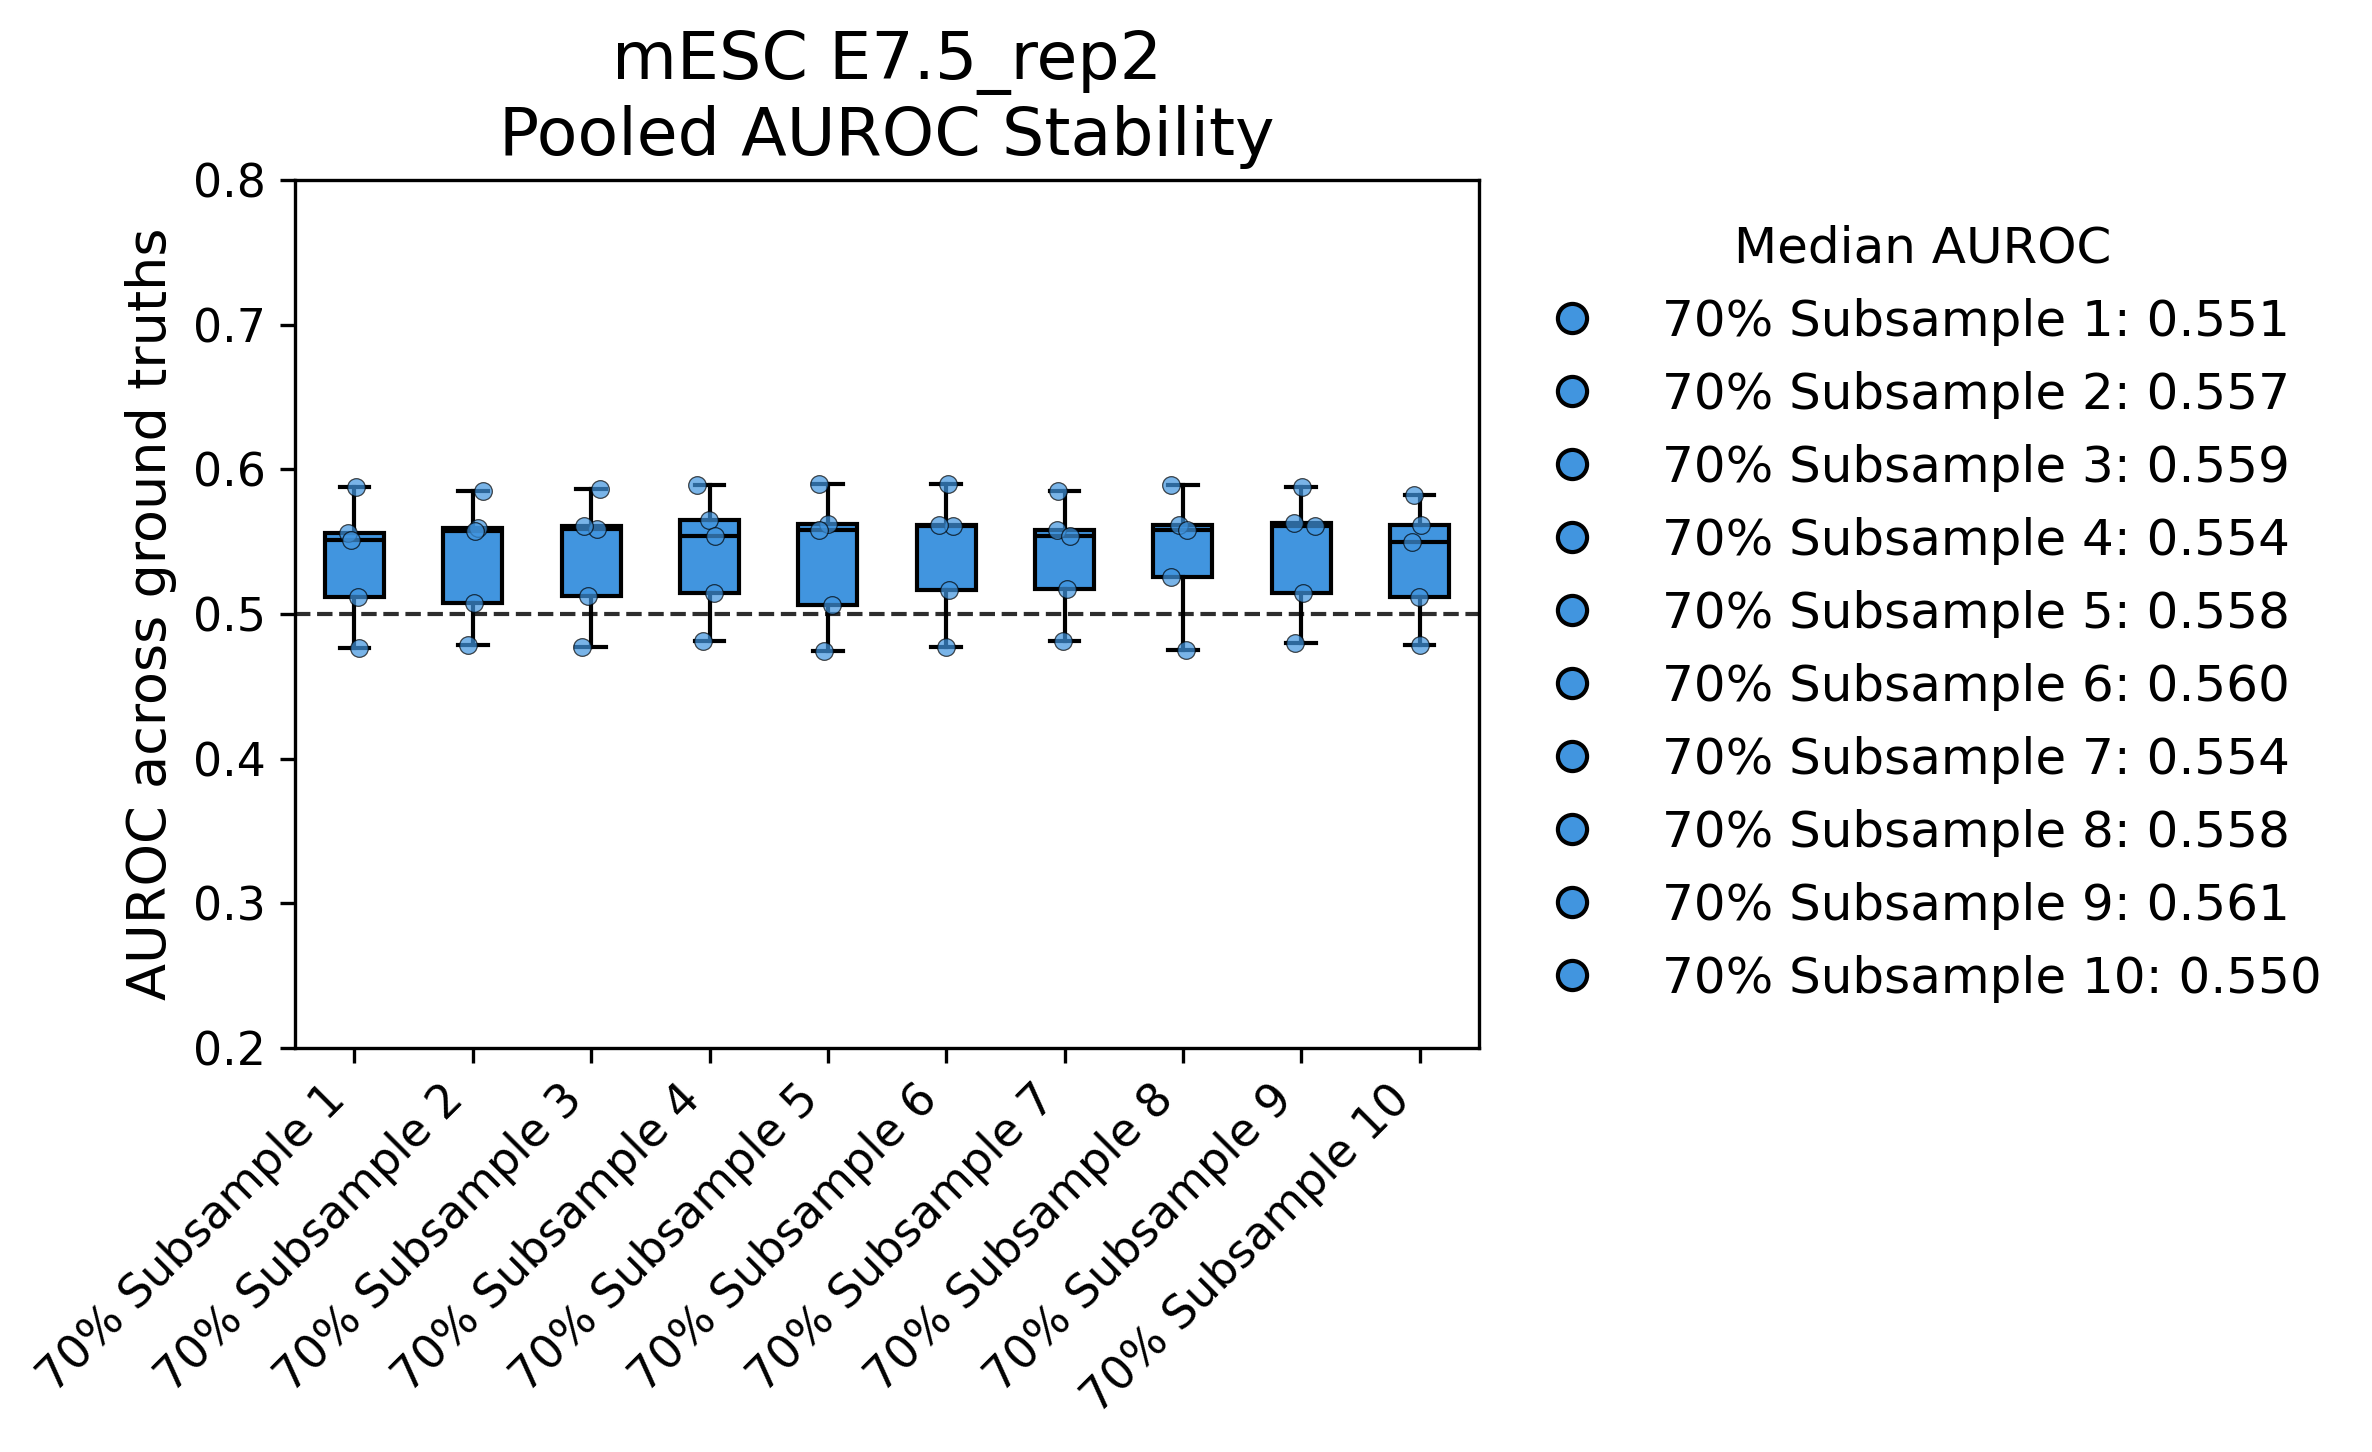

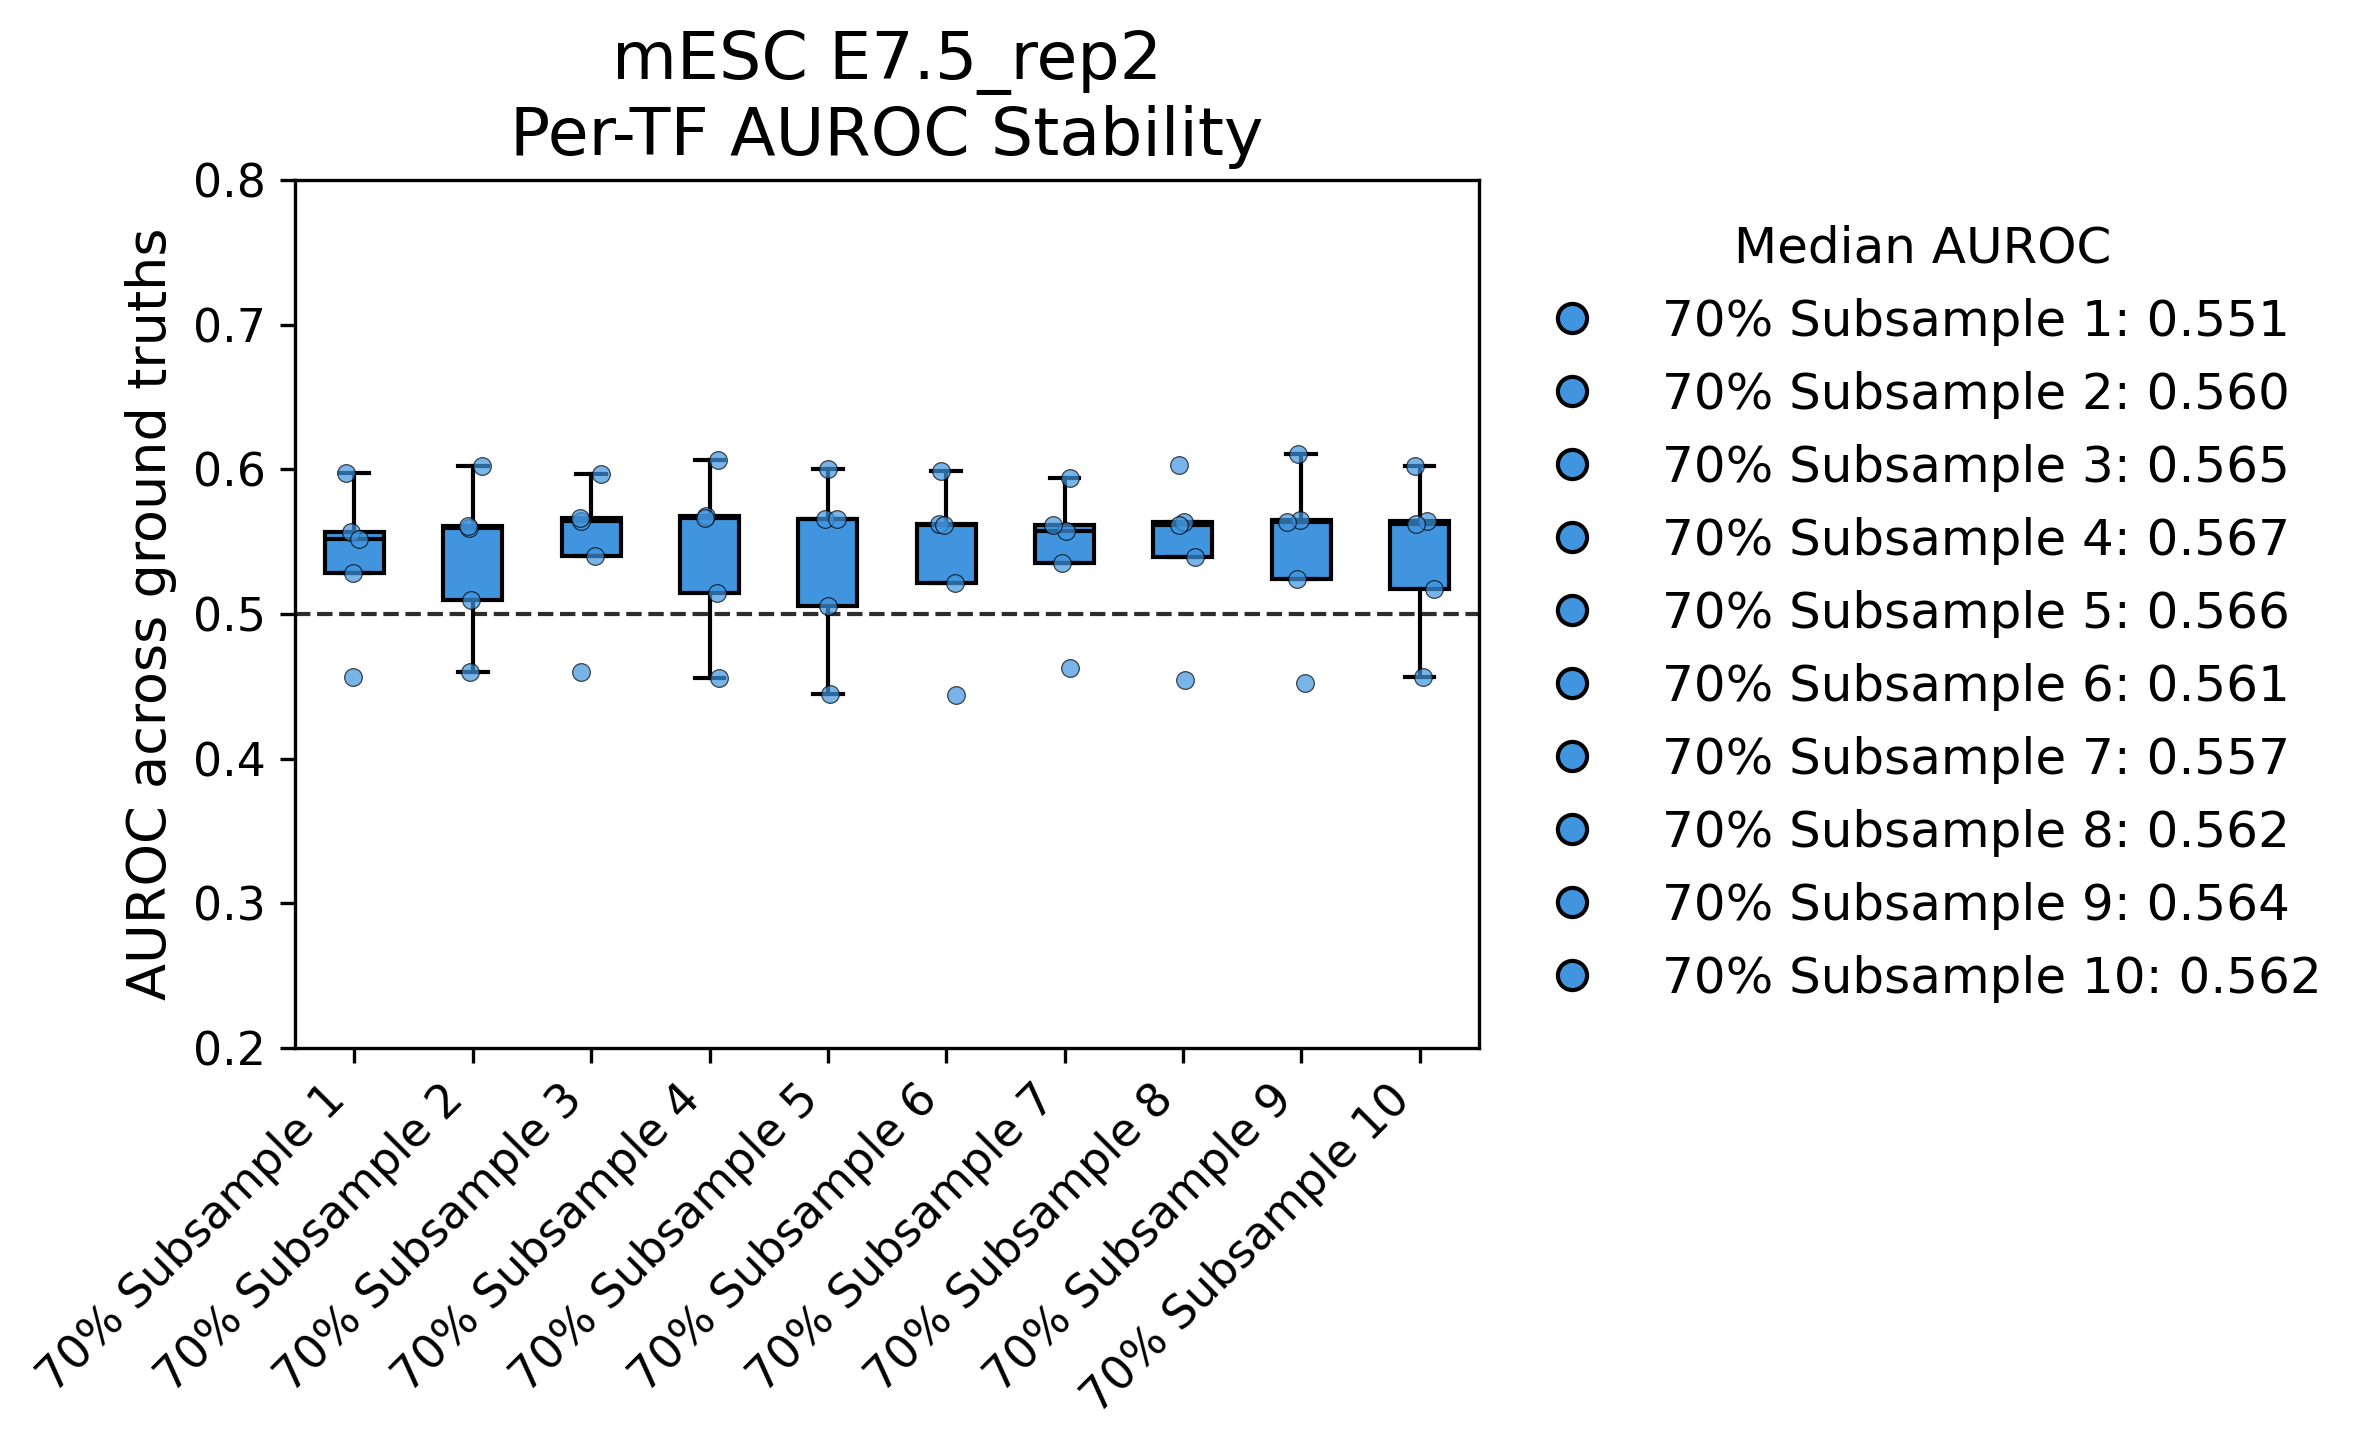

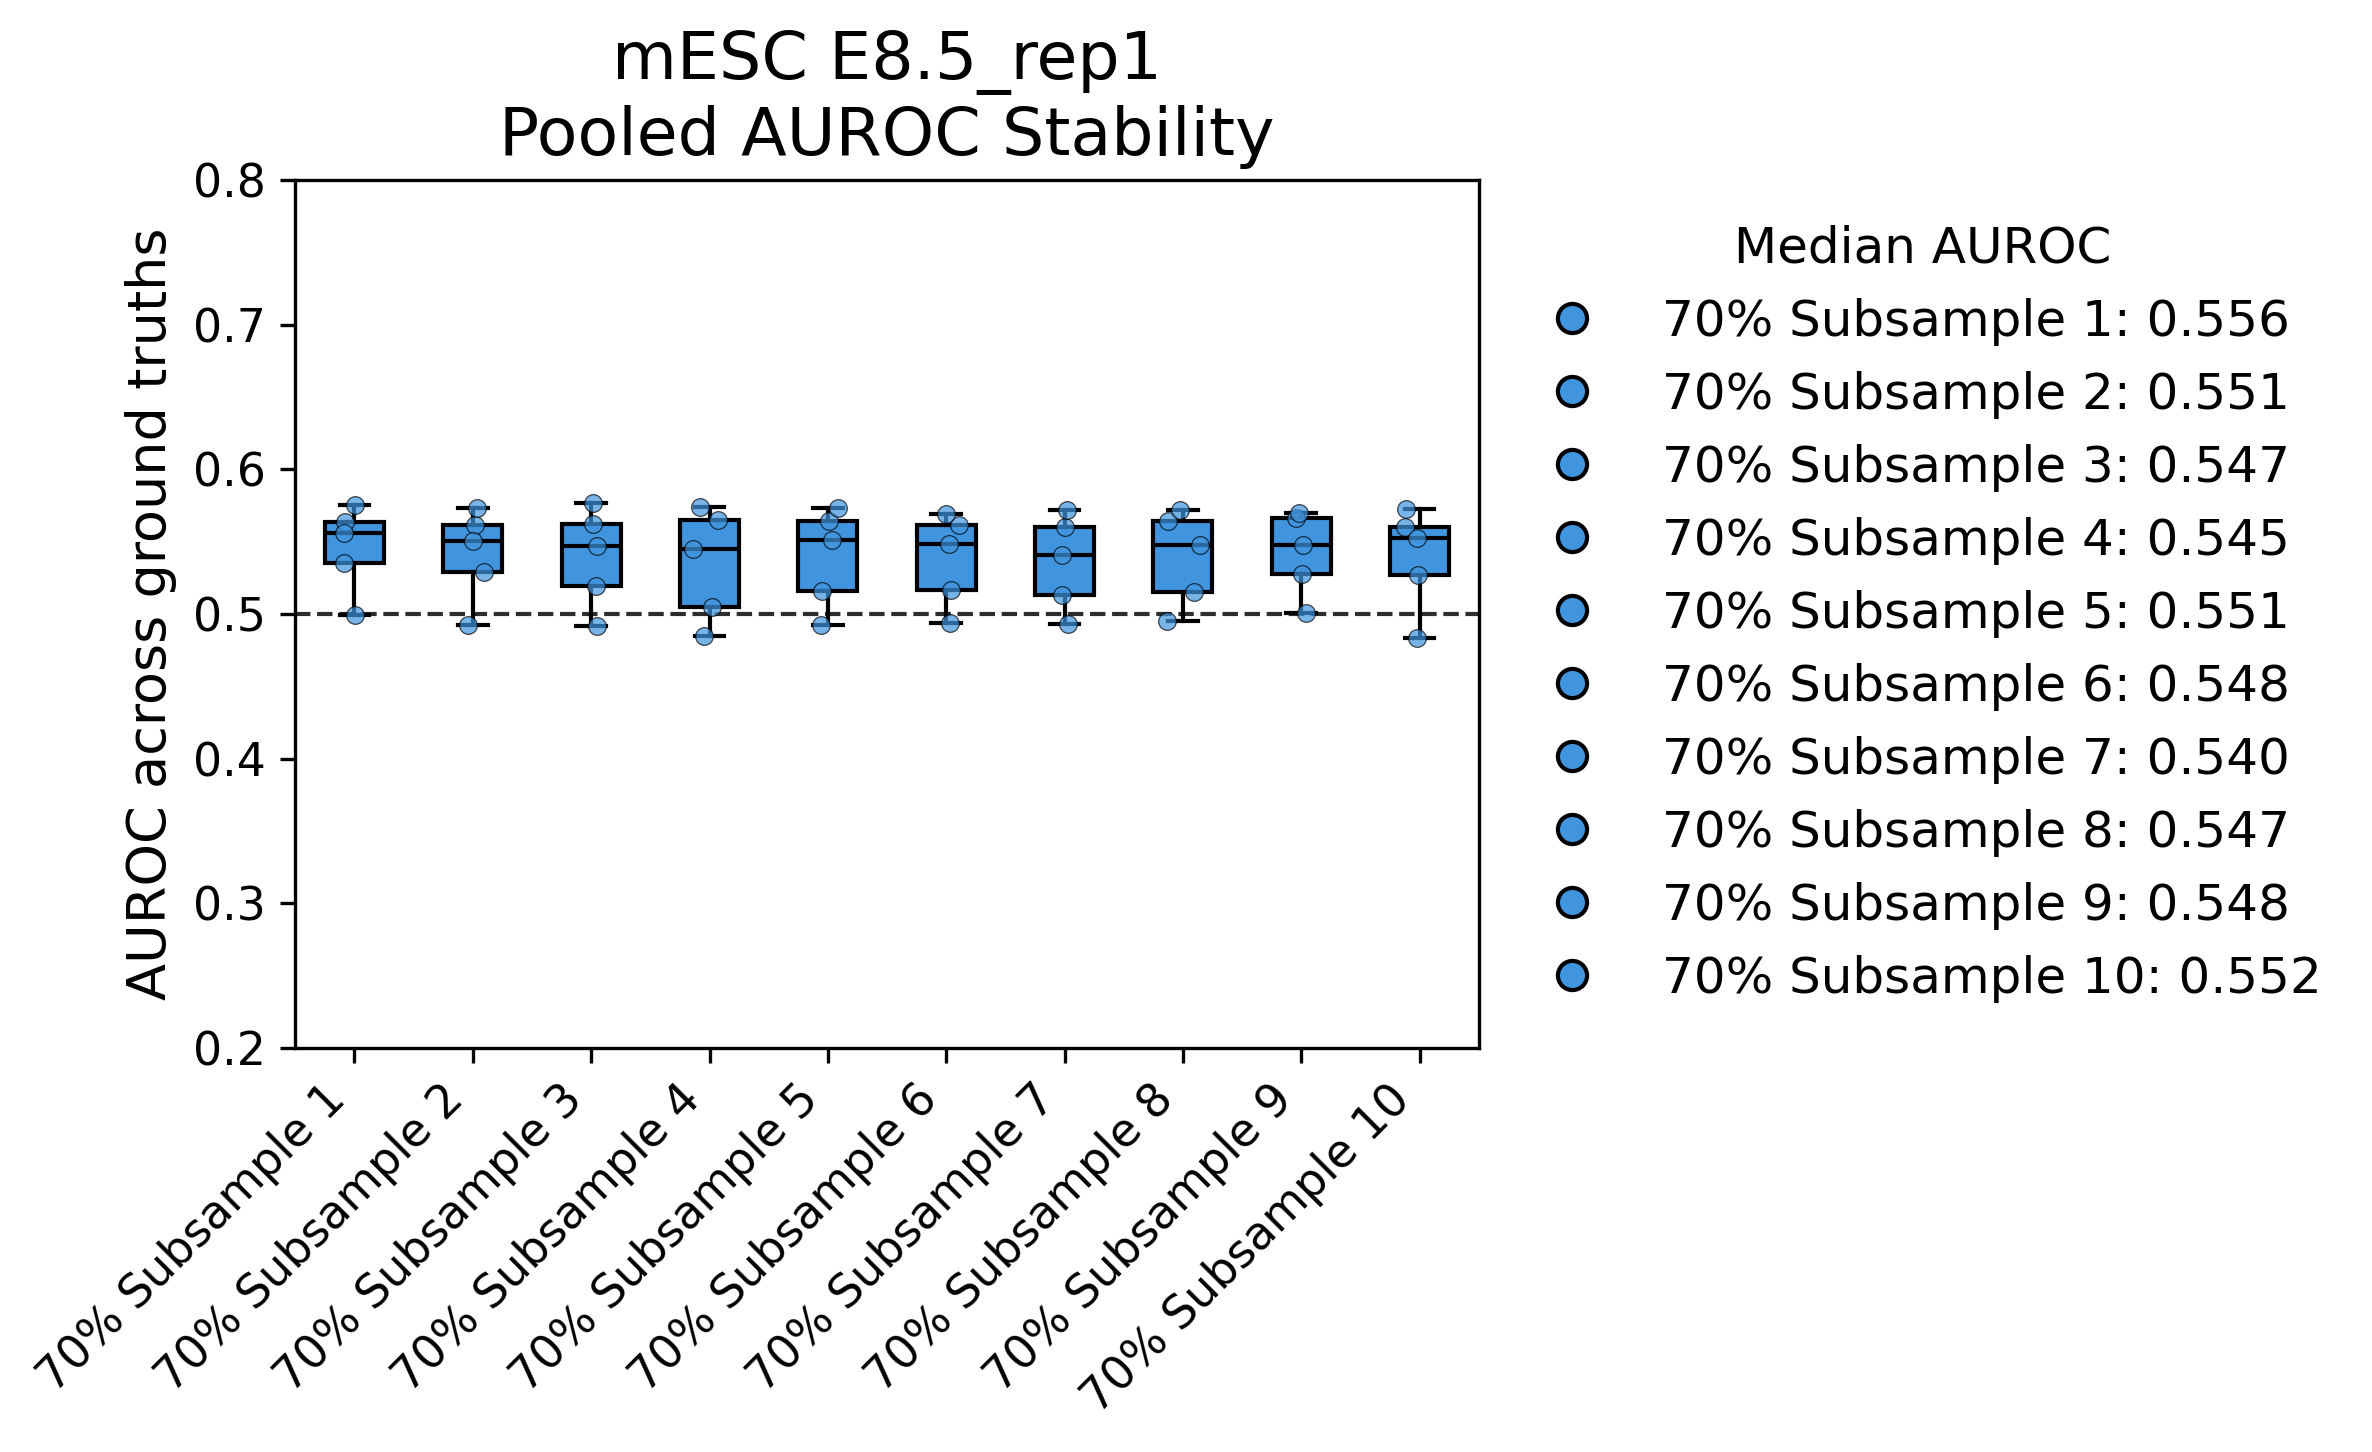

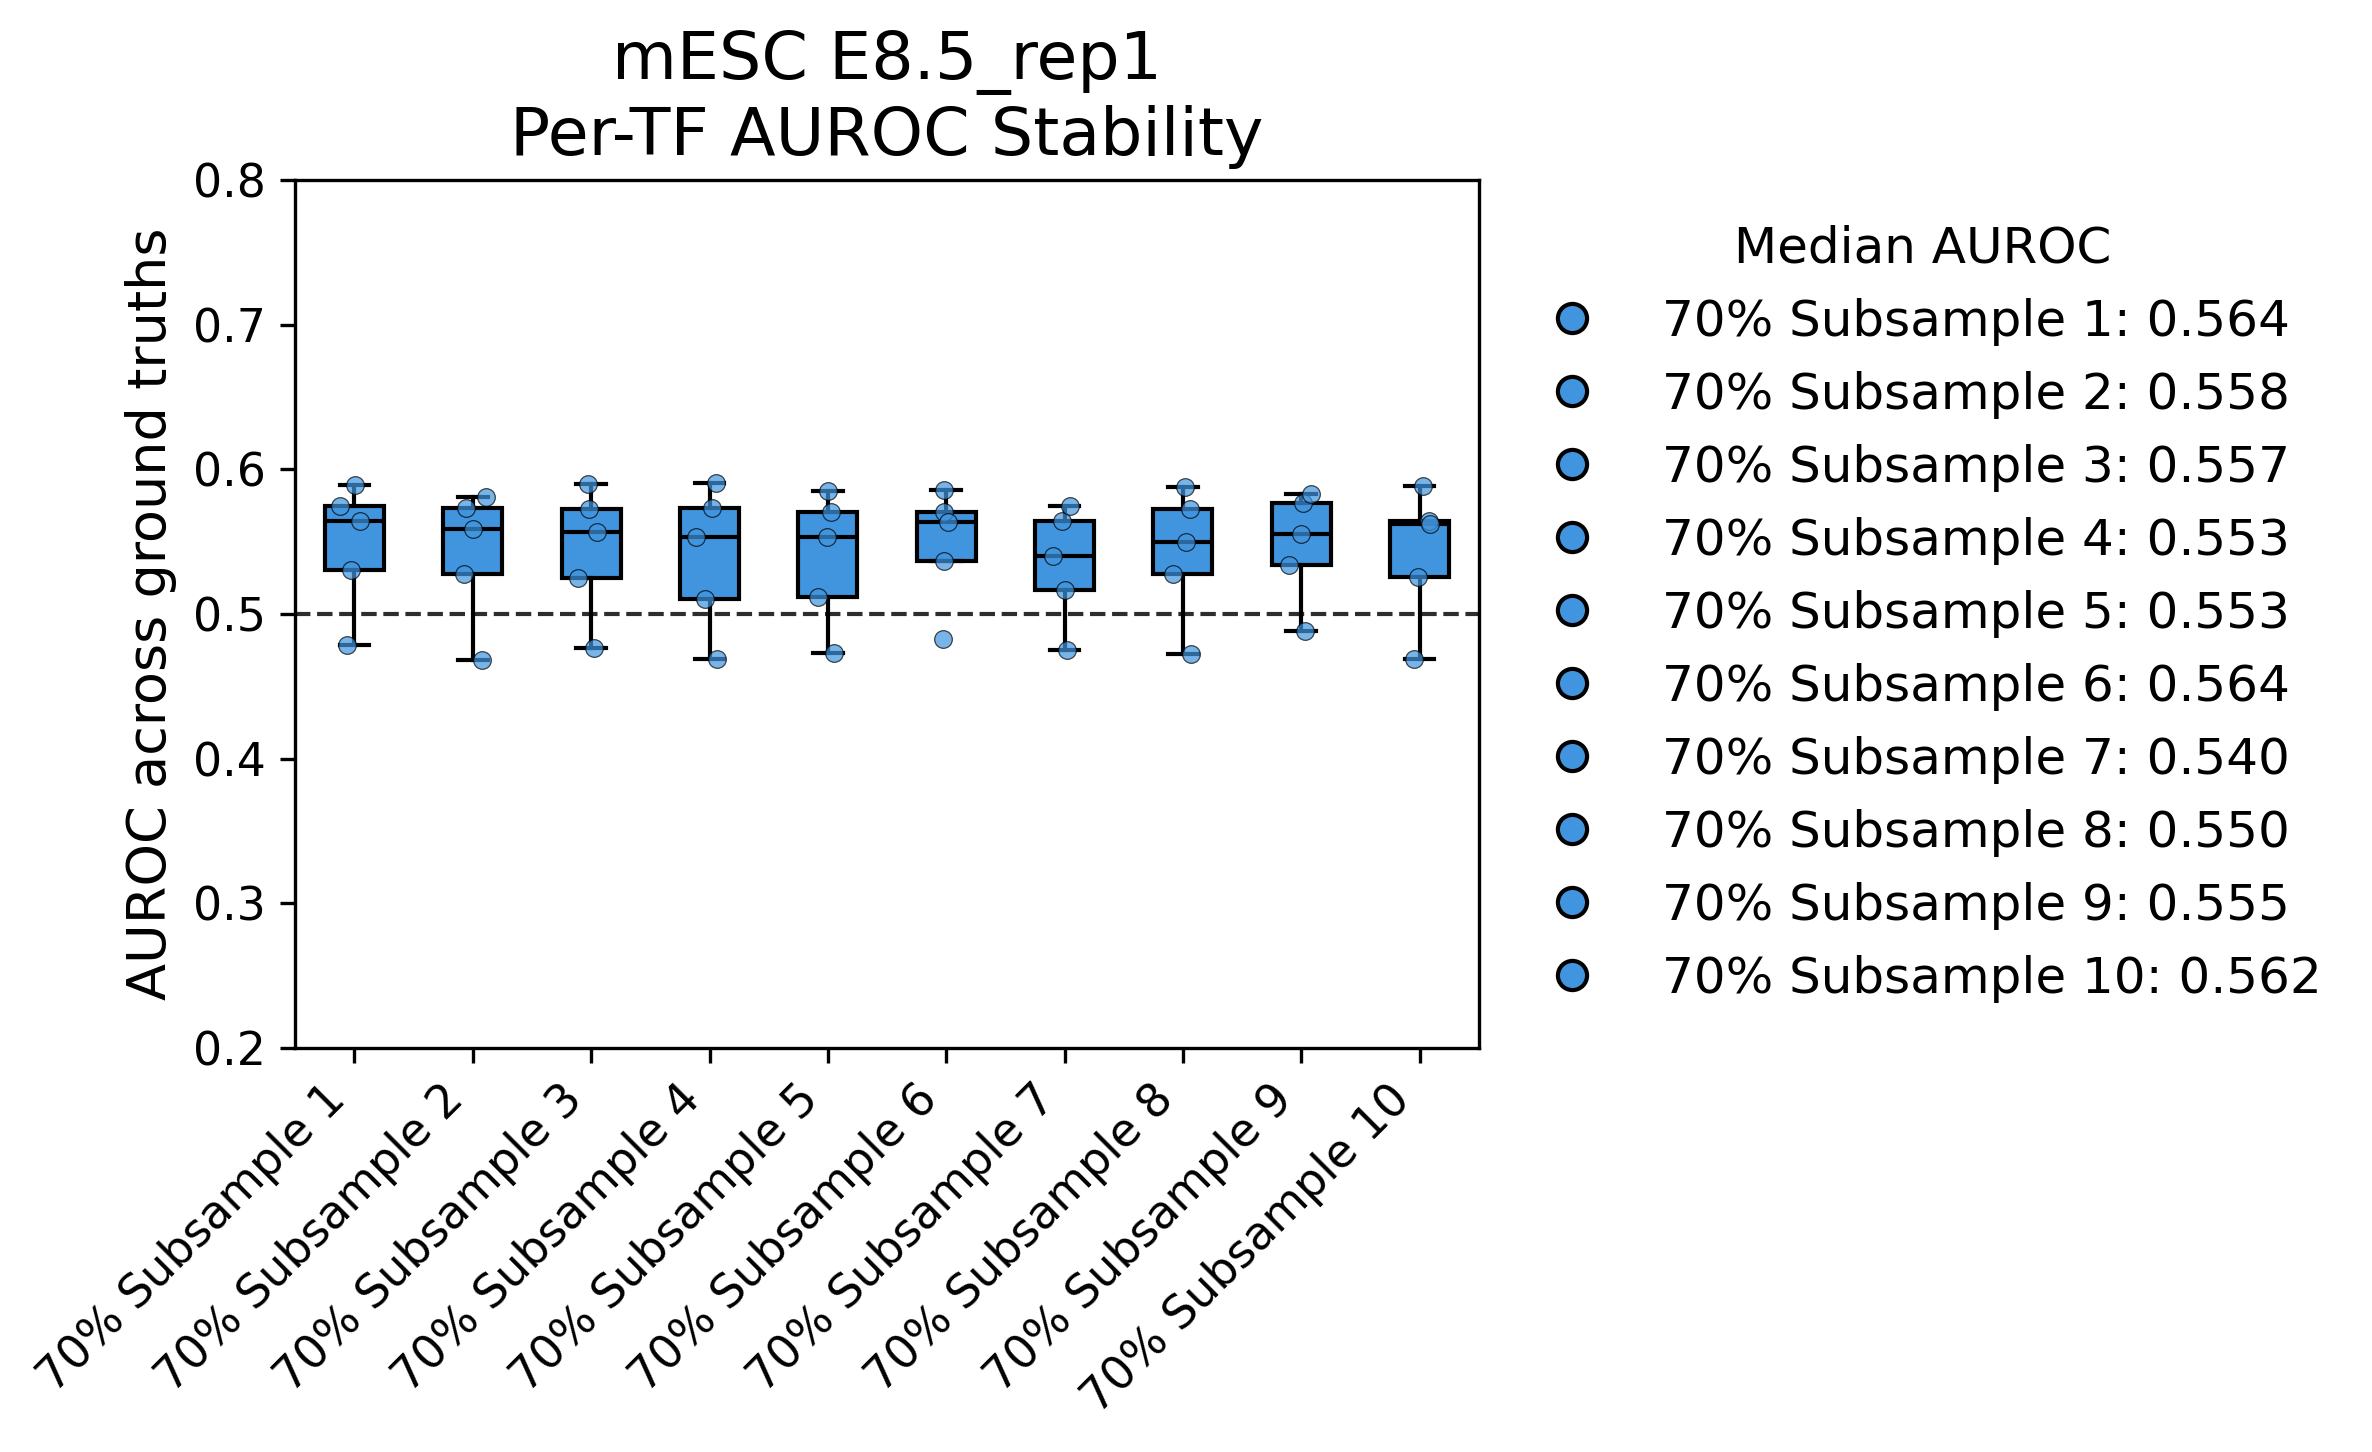

In [69]:
stability_path_groups = stability_path_df.groupby(["cell_type", "sample_name"])
for (cell_type, sample_name), group_df in stability_path_groups:
    sample_pooled_ga_plot_df_list = []
    sample_per_tf_ga_plot_df_list = []
    for model_training_dir, subsample_index in group_df[["model_training_dir", "subsample_index"]].values:

        model_training_dir = stability_path_df[
            (stability_path_df["cell_type"] == cell_type) &
            (stability_path_df["sample_name"] == sample_name) &
            (stability_path_df["subsample_index"] == subsample_index)
        ]["model_training_dir"].values[0]

        per_tf_df_all =  pd.read_csv(model_training_dir / "per_tf_auroc_auprc_results.csv")
        pooled_df_all = pd.read_csv(model_training_dir / "pooled_auroc_auprc_results.csv")

        per_tf_plot_df = (
            per_tf_df_all.dropna(subset=["auroc"])
            .groupby(['method', 'gt'], as_index=False)
            .agg(
                auroc=('auroc', 'median'),
            )
        )

        pooled_df_median_auroc = pooled_df_all[pooled_df_all["method"] == "Gradient Attribution"]["auroc"].median()
        per_tf_median_auroc = per_tf_plot_df[per_tf_plot_df["method"] == "Gradient Attribution"]["auroc"].median()

        pooled_df_ga = pooled_df_all[pooled_df_all["method"] == "Gradient Attribution"]
        per_tf_ga = per_tf_plot_df[per_tf_plot_df["method"] == "Gradient Attribution"]

        pooled_df_ga["method"] = f"70% Subsample {subsample_index}"
        per_tf_ga["method"] = f"70% Subsample {subsample_index}"
        
        pooled_df_ga["subsample_index"] = int(subsample_index)
        per_tf_ga["subsample_index"] = int(subsample_index)
        
        sample_pooled_ga_plot_df_list.append(pooled_df_ga)
        sample_per_tf_ga_plot_df_list.append(per_tf_ga)
        
    sample_pooled_ga_plot_df = pd.concat(sample_pooled_ga_plot_df_list, ignore_index=True)
    sample_per_tf_ga_plot_df = pd.concat(sample_per_tf_ga_plot_df_list, ignore_index=True)

    fig = plot_all_results_auroc_boxplot(
        sample_pooled_ga_plot_df,
        per_tf=False,
        ylim=(0.2, 0.8),
        override_title=f"{cell_type} {sample_name}\nPooled AUROC Stability",
        method_color_dict=method_color_dict,
        override_color=True,
        sort_by_median=False,
    )
    fig.show()

    fig = plot_all_results_auroc_boxplot(
        sample_per_tf_ga_plot_df, 
        per_tf=True,
        ylim=(0.2, 0.8),
        override_title=f"{cell_type} {sample_name}\nPer-TF AUROC Stability",
        method_color_dict=method_color_dict,
        override_color=True,
        sort_by_median=False,
        )
    fig.show()